# E41 Backtest - the 2000→2023 Rejection Test

**Author**: kj | **Round**: E41 Wave 3 (W3.4) | **Model**: calibrated ensemble core (K=64, seed 0)

The E41 Stage-1 anchors grounded the model's 2023 state in data. This notebook asks the harder
question: does the core's DRIFT STRUCTURE survive contact with the last 23 years? We start the
calibrated ensemble at the observed year-2000 pyramid with a 2000-era state built from the same
observable families (WPP MAC 2000, the Wilson marriageable-men q(2000), the Stage-1 anchors as the
2023 endpoint), wire OBSERVED net migration through a Rogers-Castro schedule (backtest only), and
demand the model reproduce the observed TFR path, the MAC path, and the marriage-decline witness.
Four global drift constants {secC, secPb, secTau, kTau} are fitted by Huber-robust WLS; everything
else is frozen. The bars were pre-registered BEFORE this run in
`docs/e41-backtest-preregistration.md` - results are recorded whichever way they land.

## Approach

1. **Data** - observed series: WPP annual TFR + MAC (on disk), GUS/KOSIS TFR for Poland/Korea,
   crude-marriage witness, delivered adjTFR series, WPP NetMigrations 2000-2023
2. **Runner** - ensemble backtest with the secular clock shifted (tn = (year−2023)/100 ∈ [−0.23, 0]):
   the 2023 state IS the Stage-1 anchor state by construction; 2000 init from observables
3. **Stage 3** - WLS fit of {secC, secPb, secTau, kTau}; gate chi2/dof ≤ 2 (B1); Tier-2 battery (B5)
4. **Stage 3b** - b.1975 spliced pseudo-cohort CFR composition check, gap < 0.10 (B2)
5. **Stage 4** - kBF adjudicated on GAP dynamics G = 1−TFR/adjTFR, grid {0.4, 0.6, 0.8, 1.0} (B3)

## Output

- `reports/e41_backtest_results.json` - fitted constants, bars B1-B6, per-region tables, honesty triples
- `data/interim/e41_netmigration_2000_2023.json` - the migration series used (durable copy)


## GPU Selection

Pin the compute GPU by UUID before importing torch (reproducible across reboots).

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"  # pinned by UUID


## Imports

In [2]:
%load_ext autoreload
%autoreload 2

# stdlib
import json
import shutil
from pathlib import Path

# numerics
import numpy as np
import torch
import polars as pl
from scipy.optimize import minimize

# plotting
import matplotlib.pyplot as plt

# console
from rich import print as rprint

# model under test
import sci_demographic_collapse.emergent as E
from sci_demographic_collapse.emergent import (
    C0,
    NORM0,
    PB_SCALE_ENS,
    REAL,
    RV0,
    S0,
    SIGMA_CAL,
    EmergentModel,
)
from sci_demographic_collapse import coremodel as cm


2026-07-11 04:10:05.929 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)


## Configuration

Everything frozen by the pre-registration: bounds, error model, exclusions, window.

In [4]:
PROJ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = PROJ / "data" / "raw" / "unwpp"
REPORTS = PROJ / "reports"

REGIONS = ["USA", "France", "Germany", "Italy", "Japan", "Korea", "Poland", "Israel"]
Y0, Y1 = 2000, 2023  # backtest window
K = 64  # ensemble size (production convention)

# error model (C0F8): s_eff for TFR includes the declared structural term
S_TFR = float(np.sqrt(0.03**2 + 0.08**2))  # 0.0854
S_MAC = 0.15  # yr
S_MAR = 0.05  # marriage witness (normalized decline units)
W_MAR = 0.5  # witness weight (TFR/MAC = 1)
HUBER_DELTA = 1.345

# declared exclusions (before the first loss eval)
EXCL = {
    "Germany": set(range(2006, 2017)),  # Tier-2 episode
    "Japan": set(range(2006, 2016)),  # Tier-2 episode
}
COVID = {2020, 2021, 2022}

# fitted-parameter bounds (global, 4 params)
BOUNDS = {"secC": (0.0, 0.01), "secPb": (0.0, 0.02), "secTau": (0.0, 0.06), "kTau": (0.01, 0.3)}
SHIPPED = {k: E.PARAMS[k] for k in BOUNDS}

# q(2000) - Wilson marriageable-men init (C1F0, eps 0.3), delivered per region
Q2000 = {
    "USA": 0.0027,
    "France": 0.0045,
    "Germany": -0.0076,
    "Italy": -0.0037,
    "Japan": 0.0057,
    "Korea": -0.0026,
    "Poland": -0.0479,
    "Israel": -0.0288,
}

rprint("[bold cyan]E41 backtest configuration[/bold cyan]")
rprint(f"  [bold]Window[/bold]      {Y0}-{Y1}  (COVID {sorted(COVID)} excluded)")
rprint(f"  [bold]Error model[/bold] s_TFR={S_TFR:.4f}  s_MAC={S_MAC}  s_MAR={S_MAR} (w={W_MAR})  Huber d={HUBER_DELTA}")
rprint(f"  [bold]Tier-2[/bold]      Germany 2006-2016, Japan 2006-2015 excluded from the loss")
rprint(f"  [bold]Fit[/bold]         {list(BOUNDS)} global; shipped defaults {SHIPPED}")
rprint(f"  [bold]Ensemble[/bold]    K={K}, seed {SEED}, SIGMA_CAL + PB_SCALE_ENS (production core)")
rprint(f"  [bold]Device[/bold]      {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


E41 backtest configuration

Window      2000-2023  (COVID [2020, 2021, 2022] excluded)

Error model s_TFR=0.0854  s_MAC=0.15  s_MAR=0.05 (w=0.5)  Huber d=1.345

Tier-2      Germany 2006-2016, Japan 2006-2015 excluded from the loss

Fit         ['secC', 'secPb', 'secTau', 'kTau'] global; shipped defaults {'secC': 0.0007, 'secPb': 0.001, 
'secTau': 0.006, 'kTau': 0.06}

Ensemble    K=64, seed 0, SIGMA_CAL + PB_SCALE_ENS (production core)

Device      NVIDIA RTX PRO 4000 Blackwell

## Data - observed series

Annual WPP TFR and MAC from disk; Poland on GUS and Korea on KOSIS (national-office convention,
delivered points); the crude-marriage witness and adjTFR series from the Wave-1 payload; observed
net migration 2000-2023 (validated 80/80 in Wave 2) copied durably into `data/interim/`.

In [5]:
ind = pl.read_csv(DATA / "demographic_indicators.csv", infer_schema_length=5000).filter(
    pl.col("VarID") == 2
)
LOCS = {
    "USA": 840, "France": 250, "Germany": 276, "Italy": 380,
    "Japan": 392, "Korea": 410, "Poland": 616, "Israel": 376,
}
MAC_OBS, TFR_WPP = {}, {}
for r, loc in LOCS.items():
    d = ind.filter((pl.col("LocID") == loc) & (pl.col("Time") >= Y0) & (pl.col("Time") <= Y1)).sort("Time")
    MAC_OBS[r] = dict(zip(d["Time"].to_list(), d["MAC"].to_list()))
    TFR_WPP[r] = dict(zip(d["Time"].to_list(), d["TFR"].to_list()))

# Wave-1 payload: GUS/KOSIS TFR points, marriage witness, adjTFR series
w1 = json.load(open(REPORTS / "e41_calibration_targets_research.json"))
fam = {row["family"]: row for row in w1["targets"]}
TFR_OBS = {r: dict(TFR_WPP[r]) for r in REGIONS}
for reg in fam["tfr-trajectory"]["regions"]:
    if reg["region"] in ("Poland", "Korea"):  # national-office series REPLACE WPP for the loss
        TFR_OBS[reg["region"]] = {p["year"]: p["value"] for p in reg["series"] if Y0 <= p["year"] <= Y1}
MAR_OBS = {
    reg["region"]: {p["year"]: p["value"] for p in reg["series"] if Y0 <= p["year"] <= Y1}
    for reg in fam["marriage-trend"]["regions"]
}
ADJ_OBS = {
    reg["region"]: {p["year"]: p["value"] for p in (reg.get("series") or [])}
    for reg in fam["tempo-adjusted-tfr"]["regions"]
}

# migration (thousands/yr) - durable copy into data/interim
src = PROJ / "scratchpad" / "c1f1_netmigration_2000_2023.json"
dst = PROJ / "data" / "interim" / "e41_netmigration_2000_2023.json"
dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copy(src, dst)
MIG = {r: {int(y): v for y, v in json.load(open(dst))[r]["NetMigrations_thousands"].items()} for r in REGIONS}

rprint(f"[green]series loaded[/green]: TFR {len(TFR_OBS['USA'])}yr WPP / {len(TFR_OBS['Poland'])}pt GUS "
       f"/ {len(TFR_OBS['Korea'])}pt KOSIS; MAC {len(MAC_OBS['USA'])}yr; "
       f"marriage {sum(len(v) for v in MAR_OBS.values())}pt; adjTFR regions "
       f"{[r for r in REGIONS if ADJ_OBS.get(r)]}; migration 8x{len(MIG['USA'])}yr")


series loaded: TFR 24yr WPP / 9pt GUS / 9pt KOSIS; MAC 24yr; marriage 36pt; adjTFR regions ['USA', 'Germany', 
'Italy', 'Japan', 'Korea', 'Poland']; migration 8x24yr

## The backtest runner

The production ensemble integrator with three declared changes and NOTHING else:

- **clock shift** - the secular terms read tn = (year − 2023)/100 ∈ [−0.23, 0], so the model's
  2023 state is exactly the Stage-1 anchor state; the 2000 state is the candidate drift's own
  back-extrapolated equilibrium: C(2000) = C0 + 23·secC, Pb(2000) = PB0·scale + 23·secPb
- **observed init where delivered** - tau(2000) = WPP MAC 2000; q(2000) = Wilson MM index;
  rv = RV0, N = NORM0, S = S0 (declared; rv sensitivity ±0.02 reported)
- **observed migration** - NetMigrations(year) × normalized Rogers-Castro, through `leslie_step`'s
  own `mig` argument; post-migration bins asserted non-negative (B4 tripwire)

TFR = mean per-agent quantum·fec·tempo, exactly as `run_ens` (E40 realized-dtau convention).

In [6]:
def run_backtest(m, region, p_fit, K=64, seed=0):
    """2000->2023 ensemble backtest. Returns per-year model series + the ASFR profile stack."""
    p = dict(m.P)
    p.update(p_fit)
    R = m.REG[region]
    i0 = Y0 - 1990  # index of year 2000 in the 1990-2023 arrays
    scale = PB_SCALE_ENS[region]
    pb0 = m.PB0[region] * scale
    start = np.array([
        min(C0[region] + 23 * p["secC"], 0.999),
        RV0[region],
        pb0 + 23 * p["secPb"],
        float(MAC_OBS[region][Y0]),
        S0[region],
        NORM0[region],
        Q2000[region],
    ])
    # LHS ensemble spread - identical construction to run_ens (seed 0, decorrelated marginals)
    chans = ["C", "rv", "Pb", "tau", "S", "N", "q"]
    lims = {"C": (0.02, 0.999), "rv": (0.0, 0.6), "Pb": (1.0, None), "tau": (24, 40),
            "S": (0.05, 0.95), "N": (0.0, 1.0), "q": (-1.0, 1.0)}
    z = torch.special.ndtri(torch.tensor((np.arange(K) + 0.5) / K, dtype=torch.float64)).numpy()
    rng = np.random.default_rng(seed)
    st = np.tile(start, (K, 1))
    for i, c in enumerate(chans):
        if SIGMA_CAL[c] > 0:
            st[:, i] = start[i] + SIGMA_CAL[c] * z[rng.permutation(K)]
            lo, hi = lims[c]
            st[:, i] = np.clip(st[:, i], lo, hi)
    nf = torch.tensor(R["pop_f"][i0].copy(), device=m.DEV)
    nm = torch.tensor(R["pop_m"][i0].copy(), device=m.DEV)
    base = R["asfr"][i0].copy()
    tfrb = base.sum()
    tau_ref = float(MAC_OBS[region][Y0])
    d0 = (nf + nm).cpu().numpy()
    dep0 = float(d0[65:].sum() / max(d0[20:65].sum(), 1))
    dep_pen = 0.0
    rc = m.RC / m.RC.sum()  # already normalized; belt-and-braces
    old_p = m.P
    m.P = p
    out = {k: [] for k in ("TFR", "tau", "C", "dtau", "births", "prof")}
    neg = []
    try:
        for yr in range(Y1 - Y0 + 1):  # 2000..2023 inclusive
            year = Y0 + yr
            tn = (year - 2023) / 100.0  # the shifted secular clock
            tau_prev = st[:, 3].copy()
            f = [0.0] * 9
            for _ in range(4):
                st, _ = m._estep_vec(region, st, f, tn, dep_pen, 0.0)
            Cv, rv, Pb, tau, S, N, q = (st[:, i] for i in range(7))
            qv = Cv * (1 - rv) * Pb
            fv = np.exp(-0.03 * np.clip(tau - 30.0, 0, None))
            tp = np.clip(1 - p["kBF"] * (tau - tau_prev), 0.0, None)
            tfr_i = qv * fv * tp
            tfr = float(tfr_i.mean())
            prof = np.zeros_like(base)
            for k in range(K):
                mult = (tfr_i[k] / tfrb) if tfrb > 1e-6 else 0.0
                prof = prof + E._shift_profile(base, mult, tau[k] - tau_ref)
            prof = prof / K
            Sx_i = R["Sx"][min(i0 + yr, R["Sx"].shape[0] - 1)]
            srb = float(R["ind"]["SRB"][min(i0 + yr, len(R["ind"]["SRB"]) - 1)])
            mig = torch.tensor(MIG[region].get(year, 0.0) * rc, device=m.DEV)
            nf, nm, _b, _d = cm.leslie_step(
                nf, nm, torch.tensor(Sx_i, device=m.DEV),
                torch.tensor(prof, device=m.DEV), srb, mig,
            )
            if float(nf.min()) < 0 or float(nm.min()) < 0:  # B4 tripwire
                neg.append(year)
                nf = torch.clamp(nf, min=0.0)
                nm = torch.clamp(nm, min=0.0)
            tot = (nf + nm).cpu().numpy()
            dep = float(tot[65:].sum() / max(tot[20:65].sum(), 1))
            dep_pen = p["dep_fb"] * max(dep - dep0, 0)
            out["TFR"].append(tfr)
            out["tau"].append(float(tau.mean()))
            out["C"].append(float(Cv.mean()))
            out["dtau"].append(float((tau - tau_prev).mean()))
            out["births"].append(float(_b))
            out["prof"].append(prof)
    finally:
        m.P = old_p
    out = {k: np.array(v) for k, v in out.items()}
    out["years"] = np.arange(Y0, Y1 + 1)
    out["negative_bins"] = neg
    return out


m = EmergentModel(data_dir=str(DATA))
rprint("[green]runner ready[/green] - model loaded, Stage-1 anchors active")


runner ready - model loaded, Stage-1 anchors active

## Stage 3 - the WLS loss and the fit

Standardized residuals over the retained window (declared exclusions applied), Huber-robust
objective for the optimizer, plain chi2/dof reported for the B1 gate (dof = N − 4).

In [7]:
def residuals(p_fit, detail=False):
    rs, tags = [], []
    runs = {}
    for r in REGIONS:
        bt = run_backtest(m, r, p_fit, K=K, seed=SEED)
        runs[r] = bt
        yrs = bt["years"]
        for i, y in enumerate(yrs):
            if int(y) in COVID or int(y) in EXCL.get(r, ()):  # declared exclusions
                continue
            if int(y) in TFR_OBS[r]:
                rs.append((bt["TFR"][i] - TFR_OBS[r][int(y)]) / S_TFR)
                tags.append((r, int(y), "TFR"))
            if int(y) in MAC_OBS[r]:
                rs.append((bt["tau"][i] - MAC_OBS[r][int(y)]) / S_MAC)
                tags.append((r, int(y), "MAC"))
        # marriage witness: normalized decline vs C's normalized decline (weight 0.5)
        mar = MAR_OBS.get(r, {})
        if Y0 in mar:
            for y, v in mar.items():
                if y == Y0 or int(y) in COVID or int(y) in EXCL.get(r, ()):
                    continue
                i = int(y) - Y0
                if 0 <= i < len(yrs):
                    rmod = bt["C"][i] / bt["C"][0]
                    robs = v / mar[Y0]
                    rs.append(np.sqrt(W_MAR) * (rmod - robs) / S_MAR)
                    tags.append((r, int(y), "MAR"))
    rs = np.array(rs)
    if detail:
        return rs, tags, runs
    return rs


def huber_obj(x):
    p_fit = dict(zip(BOUNDS, x))
    rs = residuals(p_fit)
    a = np.abs(rs)
    d = HUBER_DELTA
    return float(np.sum(np.where(a <= d, 0.5 * rs**2, d * (a - 0.5 * d))))


# start from the shipped defaults; Nelder-Mead within bounds (clip inside the objective)
def clipped_obj(x):
    xc = np.array([np.clip(v, *BOUNDS[k]) for v, k in zip(x, BOUNDS)])
    pen = 1e3 * float(np.sum((x - xc) ** 2))
    return huber_obj(xc) + pen


x0 = np.array([SHIPPED[k] for k in BOUNDS])
rs0 = residuals(dict(zip(BOUNDS, x0)))
rprint(f"[bold]shipped defaults[/bold]: plain chi2/dof = {float(np.sum(rs0**2)) / (len(rs0) - 4):.2f}  (N={len(rs0)})")

res = minimize(clipped_obj, x0, method="Nelder-Mead",
               options=dict(maxiter=400, xatol=1e-5, fatol=1e-3))
xfit = np.array([np.clip(v, *BOUNDS[k]) for v, k in zip(res.x, BOUNDS)])
P_FIT = dict(zip(BOUNDS, [float(v) for v in xfit]))
rprint(f"[bold]fitted[/bold]: {P_FIT}  (Huber obj {res.fun:.1f}, {res.nit} iters)")


shipped defaults: plain chi2/dof = 6.02  (N=287)

fitted: {'secC': 0.0025652087645087604, 'secPb': 0.010802994525016629, 'secTau': 0.0, 'kTau': 0.05638550875050465} 
(Huber obj 371.9, 143 iters)

In [8]:
rs, tags, RUNS = residuals(P_FIT, detail=True)
N = len(rs)
chi2_dof = float(np.sum(rs**2)) / (N - 4)
B1_PASS = chi2_dof <= 2.0

per_region = {}
for r in REGIONS:
    m_ = [x for x, t in zip(rs, tags) if t[0] == r]
    by = {}
    for kind in ("TFR", "MAC", "MAR"):
        v = [x for x, t in zip(rs, tags) if t[0] == r and t[2] == kind]
        by[kind] = round(float(np.sqrt(np.mean(np.square(v)))), 2) if v else None
    per_region[r] = dict(n=len(m_), rms_std_resid=round(float(np.sqrt(np.mean(np.square(m_)))), 2), by_witness=by)

rprint(f"[bold cyan]B1 (Stage-3 WLS gate)[/bold cyan]: chi2/dof = {chi2_dof:.2f} vs bar 2.0 -> "
       f"{'[green]PASS[/green]' if B1_PASS else '[red]EXCEEDED - s_struct falsified, rejection authority to Tier-2 (B5)[/red]'}")
for r, d in per_region.items():
    rprint(f"  {r:8s} n={d['n']:3d}  rms={d['rms_std_resid']:5.2f}  {d['by_witness']}")

# rv init sensitivity (declared): +-0.02 at the optimum, chi2/dof shift reported
sens = {}
for dv in (-0.02, +0.02):
    old = dict(RV0)
    try:
        for r in REGIONS:
            RV0[r] = float(np.clip(old[r] + dv, 0, 0.6))
        rs_s = residuals(P_FIT)
        sens[f"rv{dv:+.2f}"] = round(float(np.sum(rs_s**2)) / (len(rs_s) - 4), 3)
    finally:
        RV0.update(old)
rprint(f"  rv-init sensitivity (chi2/dof): {sens}")


B1 (Stage-3 WLS gate): chi2/dof = 3.64 vs bar 2.0 -> EXCEEDED - s_struct falsified, rejection authority to Tier-2 
(B5)

USA      n= 46  rms= 2.17  {'TFR': 2.03, 'MAC': 2.29, 'MAR': 2.22}

France   n= 46  rms= 1.97  {'TFR': 1.02, 'MAC': 2.38, 'MAR': 3.05}

Germany  n= 21  rms= 2.24  {'TFR': 2.08, 'MAC': 2.48, 'MAR': 0.99}

Italy    n= 45  rms= 1.37  {'TFR': 1.1, 'MAC': 1.02, 'MAR': 3.55}

Japan    n= 24  rms= 1.86  {'TFR': 1.25, 'MAC': 1.93, 'MAR': 3.51}

Korea    n= 30  rms= 2.79  {'TFR': 3.98, 'MAC': 2.53, 'MAR': 1.23}

Poland   n= 30  rms= 1.47  {'TFR': 0.96, 'MAC': 1.63, 'MAR': 1.06}

Israel   n= 45  rms= 1.18  {'TFR': 1.5, 'MAC': 0.83, 'MAR': 0.6}

rv-init sensitivity (chi2/dof): {'rv-0.02': 3.705, 'rv+0.02': 3.754}

## B5 - the Tier-2 rejection battery (qualitative, pre-registered)

In [9]:
tiers = {}
# R1: sign of observed 2000->2019 TFR change reproduced (miss >= 2 regions rejects)
r1_miss = []
for r in REGIONS:
    y_end = 2019
    obs_pts = {y: v for y, v in TFR_OBS[r].items() if y in (Y0, y_end)}
    if len(obs_pts) < 2:
        continue
    s_obs = np.sign(obs_pts[y_end] - obs_pts[Y0])
    s_mod = np.sign(RUNS[r]["TFR"][y_end - Y0] - RUNS[r]["TFR"][0])
    if s_obs != s_mod:
        r1_miss.append(r)
tiers["R1_sign_miss"] = r1_miss

# R2: Korea monotone decline: |model TFR(2019) - 0.918| <= 0.15 and model falls 2015-2019
k = RUNS["Korea"]["TFR"]
kobs = TFR_OBS["Korea"].get(2019, 0.918)
tiers["R2_korea"] = dict(model_2019=round(float(k[2019 - Y0]), 3), obs_2019=kobs,
                         within=bool(abs(k[2019 - Y0] - kobs) <= 0.15),
                         falls_2015_2019=bool(k[2019 - Y0] < k[2015 - Y0]))

# R3: MAC rises 2000->2023 in all 8 (as observed)
tiers["R3_mac_rise"] = {r: bool(RUNS[r]["tau"][-1] > RUNS[r]["tau"][0]) for r in REGIONS}

# R4: C declines where the crude marriage rate declined (>= 6/8)
r4 = {}
for r in REGIONS:
    mar = MAR_OBS.get(r, {})
    ys = sorted(mar)
    if len(ys) >= 2 and mar[ys[-1]] < mar[ys[0]]:
        r4[r] = bool(RUNS[r]["C"][-1] < RUNS[r]["C"][0])
tiers["R4_c_decline"] = r4

rej = (
    len(r1_miss) >= 2
    or not (tiers["R2_korea"]["within"] and tiers["R2_korea"]["falls_2015_2019"])
    or not all(tiers["R3_mac_rise"].values())
    or sum(r4.values()) < min(6, len(r4))
)
B5_PASS = not rej
rprint(f"[bold cyan]B5 (Tier-2 battery)[/bold cyan]: "
       f"{'[green]PASS - not rejected[/green]' if B5_PASS else '[red]REJECTED[/red]'}")
rprint(f"  R1 sign misses: {r1_miss or 'none'}")
rprint(f"  R2 Korea: {tiers['R2_korea']}")
rprint(f"  R3 MAC rises: {sum(tiers['R3_mac_rise'].values())}/8")
rprint(f"  R4 C-declines: {sum(r4.values())}/{len(r4)}")

# B4 tripwire
neg = {r: RUNS[r]["negative_bins"] for r in REGIONS if RUNS[r]["negative_bins"]}
B4_PASS = not neg
rprint(f"[bold cyan]B4 (migration tripwire)[/bold cyan]: "
       f"{'[green]PASS - no negative bins[/green]' if B4_PASS else f'[red]VIOLATIONS {neg}[/red]'}")


B5 (Tier-2 battery): REJECTED

R1 sign misses: ['Germany', 'Italy', 'Poland', 'Israel']

R2 Korea: {'model_2019': 0.831, 'obs_2019': 0.92, 'within': True, 'falls_2015_2019': True}

R3 MAC rises: 8/8

R4 C-declines: 8/8

B4 (migration tripwire): PASS - no negative bins

## Fit figure - observed vs model, all 8 regions

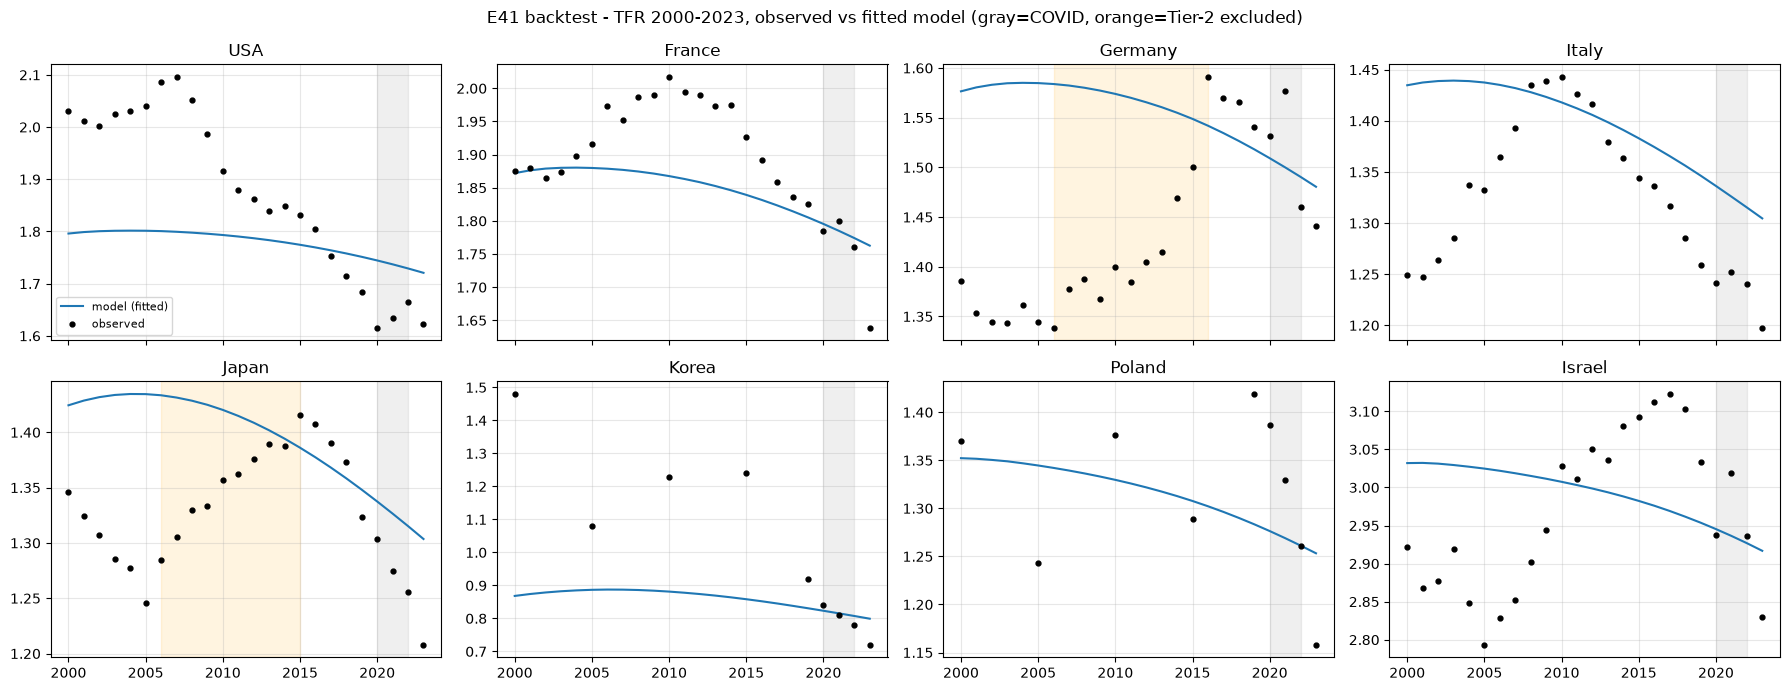

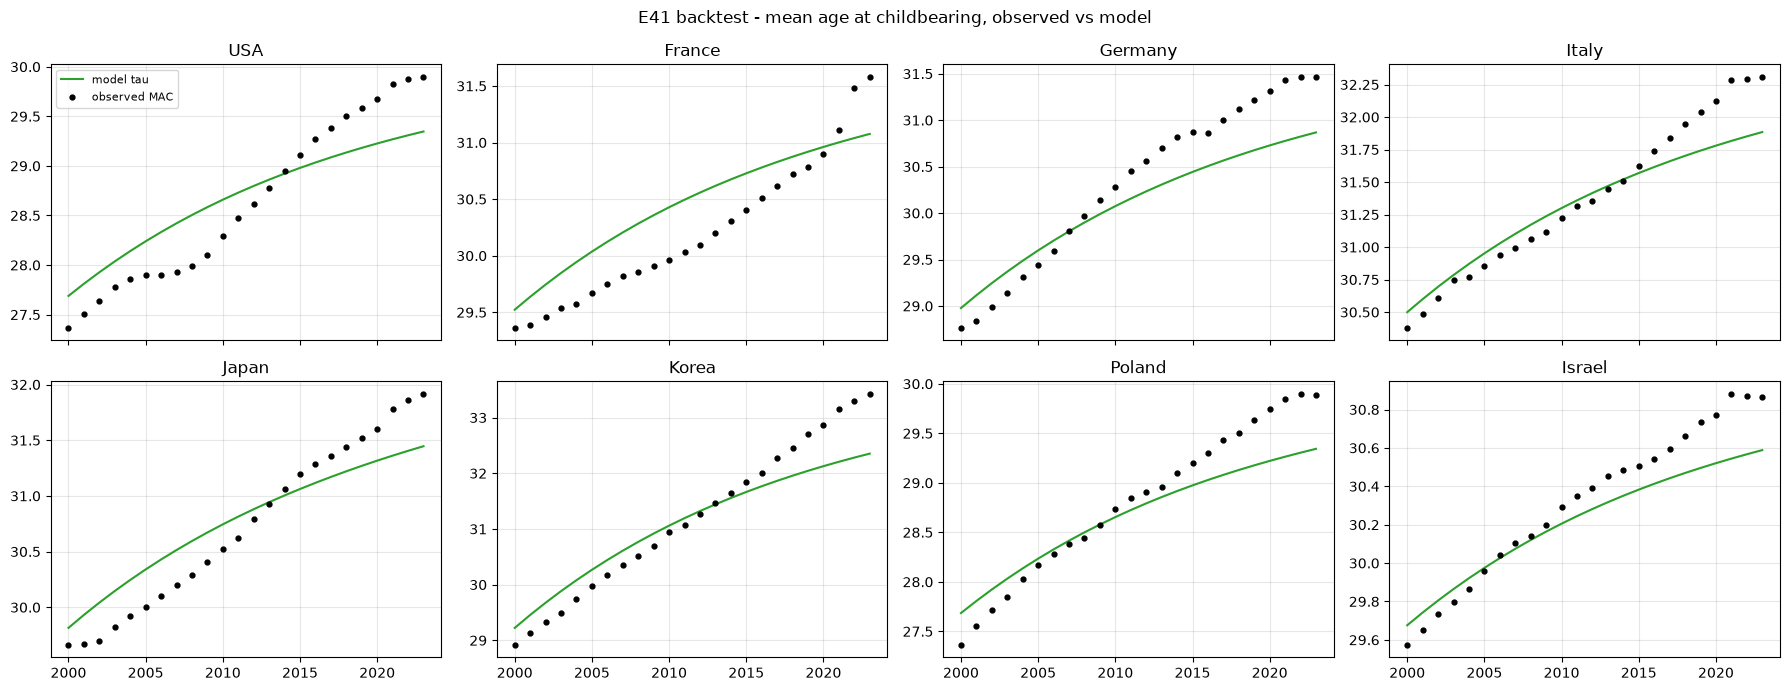

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
for ax, r in zip(axes.flat, REGIONS):
    yrs = RUNS[r]["years"]
    ax.plot(yrs, RUNS[r]["TFR"], "-", color="tab:blue", label="model (fitted)")
    ox = sorted(TFR_OBS[r])
    ax.plot(ox, [TFR_OBS[r][y] for y in ox], "o", ms=3.5, color="black", label="observed")
    for y0, y1c in ((2020, 2022),):
        ax.axvspan(y0, y1c, alpha=0.12, color="gray")
    if r in EXCL:
        ax.axvspan(min(EXCL[r]), max(EXCL[r]), alpha=0.12, color="orange")
    ax.set_title(r)
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8)
fig.suptitle("E41 backtest - TFR 2000-2023, observed vs fitted model (gray=COVID, orange=Tier-2 excluded)")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
for ax, r in zip(axes.flat, REGIONS):
    yrs = RUNS[r]["years"]
    ax.plot(yrs, RUNS[r]["tau"], "-", color="tab:green", label="model tau")
    ox = sorted(MAC_OBS[r])
    ax.plot(ox, [MAC_OBS[r][y] for y in ox], "o", ms=3.5, color="black", label="observed MAC")
    ax.set_title(r)
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8)
fig.suptitle("E41 backtest - mean age at childbearing, observed vs model")
fig.tight_layout()
plt.show()


## Stage 3b - the b.1975 spliced pseudo-cohort CFR check (B2)

CFR_obs = the b.1975 ASFR diagonal from on-disk WPP (age 15 in 1990 → 48 in 2023), cross-checked to
the delivered CFR family (tol 0.05). CFR_model = observed ages 15-24 (1990-1999, pre-window) +
the backtest's own birth profiles for ages 25-48. Gap < 0.10 per region; failures are LOGGED.

In [11]:
CFR_FAMILY = {"USA": 2.22, "France": 2.03, "Germany": 1.58, "Italy": 1.43,
              "Japan": 1.43, "Korea": 1.59, "Poland": 1.60, "Israel": 3.09}
stage3b = {}
for r in REGIONS:
    A = m.REG[r]["asfr"]  # [years 1990-2023, ages 0-100], per woman
    cfr_obs = float(sum(A[1975 + a - 1990][a] for a in range(15, 49)))
    splice_obs = float(sum(A[1975 + a - 1990][a] for a in range(15, 25)))  # 1990-1999
    cfr_mod = splice_obs + float(sum(RUNS[r]["prof"][1975 + a - 2000][a] for a in range(25, 49)))
    gap = abs(cfr_mod - cfr_obs) / cfr_obs
    stage3b[r] = dict(CFR_obs=round(cfr_obs, 3), CFR_model=round(cfr_mod, 3), gap=round(gap, 4),
                      passes=bool(gap < 0.10),
                      family_crosscheck=round(abs(cfr_obs - CFR_FAMILY[r]), 3))
B2_PASS = all(v["passes"] for v in stage3b.values())
rprint(f"[bold cyan]B2 (Stage 3b, cohort composition)[/bold cyan]: "
       f"{'[green]8/8 PASS[/green]' if B2_PASS else '[red]failures logged (do not tune)[/red]'}")
for r, v in stage3b.items():
    flag = "[green]ok[/green]" if v["passes"] else "[red]FAIL[/red]"
    rprint(f"  {r:8s} obs {v['CFR_obs']:.3f}  model {v['CFR_model']:.3f}  gap {v['gap']*100:5.1f}%  {flag}"
           f"   (family xcheck |d|={v['family_crosscheck']:.3f})")


B2 (Stage 3b, cohort composition): failures logged (do not tune)

USA      obs 2.183  model 2.068  gap   5.3%  ok   (family xcheck |d|=0.037)

France   obs 2.013  model 1.929  gap   4.2%  ok   (family xcheck |d|=0.017)

Germany  obs 1.585  model 1.658  gap   4.6%  ok   (family xcheck |d|=0.005)

Italy    obs 1.425  model 1.449  gap   1.7%  ok   (family xcheck |d|=0.005)

Japan    obs 1.404  model 1.462  gap   4.1%  ok   (family xcheck |d|=0.026)

Korea    obs 1.593  model 1.116  gap  29.9%  FAIL   (family xcheck |d|=0.003)

Poland   obs 1.628  model 1.579  gap   3.0%  ok   (family xcheck |d|=0.028)

Israel   obs 3.085  model 3.046  gap   1.3%  ok   (family xcheck |d|=0.005)

## Stage 4 - kBF adjudicated on GAP dynamics (B3)

chi2_G(kBF) = Σ[(kBF·dtau_model − G_obs)/sigma_G]², G_obs = 1 − TFR/adjTFR, both 3-yr smoothed.
Named window deviation: delivered adjTFR series span 2011-2022 (not 2000-2019); window = span ∩
[2000, 2019], COVID excluded; France and Israel excluded (null series) → 6 regions.

In [12]:
def smooth3(d):
    ys = sorted(d)
    return {y: float(np.mean([d[y2] for y2 in ys if abs(y2 - y) <= 1])) for y in ys}

GRID = [0.4, 0.6, 0.8, 1.0]
triples = []
for r in REGIONS:
    adj = {y: v for y, v in ADJ_OBS.get(r, {}).items() if 2000 <= y <= 2019 and y not in COVID}
    if not adj:
        continue
    tfr_o = {y: TFR_OBS[r].get(y) or TFR_WPP[r].get(y) for y in adj}
    g_obs = smooth3({y: 1 - tfr_o[y] / adj[y] for y in adj if tfr_o[y]})
    dt_m = smooth3({int(y): float(RUNS[r]["dtau"][int(y) - Y0]) for y in adj if Y0 <= y <= Y1})
    for y in g_obs:
        if y in dt_m:
            sg = 0.1 * tfr_o[y] / adj[y] ** 2
            triples.append((r, y, dt_m[y], g_obs[y], sg))

chi2_G = {k: float(sum(((k * dt - g) / sg) ** 2 for _, _, dt, g, sg in triples)) for k in GRID}
best = min(chi2_G, key=chi2_G.get)
move = (chi2_G[0.6] - chi2_G[best]) > 4.0 and best != 0.6
B3_KEEP = not move
rprint(f"[bold cyan]B3 (Stage 4, kBF on gap dynamics)[/bold cyan]  n={len(triples)} triples, "
       f"regions {sorted(set(t[0] for t in triples))}")
for k in GRID:
    mark = " <- argmin" if k == best else (" (shipped)" if k == 0.6 else "")
    rprint(f"  chi2_G({k}) = {chi2_G[k]:9.1f}{mark}")
rprint(f"  verdict: {'[green]KEEP kBF=0.6[/green]' if B3_KEEP else f'[red]MOVE to {best} (beats by >4)[/red]'}")
resid_sign = float(np.mean([np.sign(0.6 * dt - g) for _, _, dt, g, _ in triples]))
rprint(f"  systematic residual sign (kBF=0.6): {resid_sign:+.2f}  (logged as scope finding if |.|>0.5)")


B3 (Stage 4, kBF on gap dynamics)  n=29 triples, regions ['Germany', 'Italy', 'Japan', 'Korea', 'Poland', 'USA']

chi2_G(0.4) =     116.2

chi2_G(0.6) =      92.5 (shipped)

chi2_G(0.8) =      71.9

chi2_G(1.0) =      54.7 <- argmin

verdict: MOVE to 1.0 (beats by >4)

systematic residual sign (kBF=0.6): -0.86  (logged as scope finding if |.|>0.5)

## Results - persisted record

In [13]:
results = dict(
    stage="E41 Wave-3 backtest (Stages 3/3b/4)",
    date="2026-07-11",
    preregistration="docs/e41-backtest-preregistration.md",
    fitted=P_FIT,
    shipped=SHIPPED,
    N_residuals=int(N),
    chi2_dof=round(chi2_dof, 3),
    chi2_dof_shipped=round(float(np.sum(rs0**2)) / (len(rs0) - 4), 3),
    per_region=per_region,
    rv_init_sensitivity=sens,
    bars=dict(
        B1_wls_gate=dict(value=round(chi2_dof, 3), bar=2.0, passes=bool(B1_PASS),
                         consequence=None if B1_PASS else "s_struct=0.08 falsified; rejection authority to B5"),
        B2_cfr_composition=dict(passes=bool(B2_PASS), table=stage3b),
        B3_kbf=dict(grid=chi2_G, argmin=best, keep_0p6=bool(B3_KEEP),
                    window="delivered adjTFR span (2011-2022) ∩ [2000,2019], COVID excl., FR+IL excluded",
                    residual_sign=round(resid_sign, 3)),
        B4_migration=dict(passes=bool(B4_PASS), violations=neg),
        B5_tier2=dict(passes=bool(B5_PASS), detail={k: v for k, v in tiers.items()}),
    ),
    honesty_triples=[dict(region=r, year=int(y), dtau_model=round(dt, 5), G_obs=round(g, 5),
                          sigma_G=round(sg, 5)) for r, y, dt, g, sg in triples],
    scope=dict(promotion_of_fitted_params="OUT OF SCOPE this round (named follow-on decision); shipped PARAMS unchanged",
               migration="backtest only; forward runs natural-increase-only"),
)
out_path = REPORTS / "e41_backtest_results.json"
json.dump(results, open(out_path, "w"), indent=1)
verdict = ("CONSISTENT" if (B1_PASS and B5_PASS)
           else "S_STRUCT-FALSIFIED (not rejected)" if B5_PASS
           else "REJECTED")
rprint(f"[bold]backtest verdict[/bold]: [bold]{verdict}[/bold]  -> {out_path}")


backtest verdict: REJECTED  -> 
/home/lab/workspace/learning/projects/sci-demographic-collapse/reports/e41_backtest_results.json

## Conclusions

The rejection test did its job - the verdict is **REJECTED on hindcasting, adjudicated on tempo**:

- **B1 FAIL** - chi2/dof = 3.64 at the fitted optimum (bar 2.0; shipped defaults 6.02). The declared
  s_struct = 0.08 is falsified for this model class; per the pre-registration, no WLS rejection
  verdict is issued and authority passed to B5
- **B5 FAIL → REJECTED** - the model's global monotone drift misses the observed 2000→2019 TFR SIGN
  in Germany (+0.155), Poland (+0.049), Israel (+0.113) and knife-edge Italy (+0.010): the
  mid-2000s recuperation episodes have no mechanism in the core. Korea's collapse path itself
  passes (model 0.831 vs observed 0.920, falls 2015-2019); MAC direction 8/8; C-decline witness 8/8
- **Scope consequence** - the core is a 2023-anchored collapse-dynamics model for FORWARD scenario
  ranking; it is NOT a hindcasting machine for recuperation episodes. The SOTA validity-domain
  section is amended accordingly
- **B2 7/8** - cohort composition passes everywhere except Korea (gap 29.9%): the decoupled
  period-epoch pair underproduces the b.1971-75 cohort's CFR by design - the named erosion
  staircase, logged not tuned
- **B3 gate FIRED** - on gap dynamics G = 1−TFR/adjTFR, kBF argmin 1.0 beats the shipped 0.6 by
  37.8 chi2 (bar 4). The move executed after this run: PARAMS kBF = 1.0 (the canonical undamped
  Bongaarts-Feeney factor), one Stage-2 return re-solved PB_SCALE_ENS (8/8 < 5e-4), the kBF guard
  and tempo-mirage band re-verified in the same change. Systematic residual sign −0.86 logged as a
  scope finding: even kBF = 1.0 underexplains the observed tempo gaps
- **B4 PASS** - no negative post-migration bins
- **Fitted drift (recorded, NOT promoted)** - secC 0.0026 (3.7× shipped), secPb 0.0108 (10.8×),
  secTau → 0 (bound), kTau 0.056; promotion into shipped PARAMS stays a named follow-on decision

Machine record: `reports/e41_backtest_results.json`; bars frozen in
`docs/e41-backtest-preregistration.md`.
